# HR Employee Attrition Analysis

## Project Objective
Analyze employee attrition to identify the major factors associated with employee turnover and provide business-focused insights for HR teams.

### Business Questions
1. What is the overall employee attrition rate?
2. Which departments have the highest attrition rate?
3. Is overtime associated with higher attrition?
4. Which job roles show higher attrition risk?
5. Does salary level appear related to attrition?
6. How do tenure, income, and distance from home differ between employees who left and those who stayed?
7. What practical HR actions can be suggested from the findings?

**Workflow:** Phase 1 → Raw Data Understanding → Phase 2 → Data Cleaning → EDA → Business Insights → Conclusion

## Phase 1 — Raw Data Understanding
**Rule:** Phase 1 only inspects the raw dataset. No cleaning or modification is performed.

In [1]:
# Libraries Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
# Dataset Load
df = pd.read_csv("../data/HR_Employee_Attrition_RAW.csv")

pd.set_option("display.max_columns", None)
df.head()

,EmployeeID,Age,Gender,Education,Department,JobRole,JobLevel,MonthlyIncome,SalarySlab,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsWithCurrentManager,OverTime,BusinessTravel,DistanceFromHome,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating,PercentSalaryHike,StockOptionLevel,TrainingTimesLastYear,NumCompaniesWorked,SickLeaveDays,AbsentDays,MaritalStatus,Attrition,JoiningDate,EmployeeNumber
0,EMP10001,23,Male,Bachelor's,Research & Development,Laboratory Technician,1,25000.0,Very High,0,0.0,0,0,No,Travel_Frequently,22.0,High,Medium,High,Medium,3,18,3,5,0,1,18,Single,No,03-12-2013,528084
1,EMP10002,26,Female,Master's,Marketing,Marketing Executive,2,13564.0,High,0,0.0,0,0,NO,Travel_Rarely,15.0,Very High,Low,Low,Low,3,16,2,4,1,9,3,Married,No,06-02-2014,842920
2,EMP10003,54,Female,Master's,Finance,Finance Manager,2,0.0,Very High,27,0.0,0,0,No,Travel_Frequently,20.0,Low,Low,High,Very High,3,18,1,4,3,4,1,Married,No,01-04-2015,834848
3,EMP10004,28,Female,PhD,Human Resources,HR Executive,2,25000.0,Very High,3,2.0,2,1,No,Travel_Rarely,27.0,Very High,Medium,High,Medium,3,24,1,1,0,9,18,Single,No,26-03-2010,579630
4,EMP10005,27,Female,Master's,Sales,Sales Executive,2,25000.0,Very High,1,1.0,0,1,No,Travel_Rarely,28.0,High,Medium,Medium,Low,3,17,1,1,3,8,18,Married,No,04-10-2017,179704


In [3]:
# Dataset Shape
df.shape

(2520, 31)

In [4]:
# Column Names
df.columns

Index(['EmployeeID', 'Age', 'Gender', 'Education', 'Department', 'JobRole',
       'JobLevel', 'MonthlyIncome', 'SalarySlab', 'TotalWorkingYears',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrentManager',
       'OverTime', 'BusinessTravel', 'DistanceFromHome', 'JobSatisfaction',
       'EnvironmentSatisfaction', 'WorkLifeBalance', 'JobInvolvement',
       'PerformanceRating', 'PercentSalaryHike', 'StockOptionLevel',
       'TrainingTimesLastYear', 'NumCompaniesWorked', 'SickLeaveDays',
       'AbsentDays', 'MaritalStatus', 'Attrition', 'JoiningDate',
       'EmployeeNumber'],
      dtype='object')

In [5]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2520 entries, 0 to 2519
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeID               2520 non-null   object 
 1   Age                      2520 non-null   int64  
 2   Gender                   2520 non-null   object 
 3   Education                2508 non-null   object 
 4   Department               2520 non-null   object 
 5   JobRole                  2506 non-null   object 
 6   JobLevel                 2520 non-null   int64  
 7   MonthlyIncome            2502 non-null   float64
 8   SalarySlab               2520 non-null   object 
 9   TotalWorkingYears        2520 non-null   int64  
 10  YearsAtCompany           2510 non-null   float64
 11  YearsInCurrentRole       2520 non-null   int64  
 12  YearsWithCurrentManager  2520 non-null   int64  
 13  OverTime                 2510 non-null   object 
 14  BusinessTravel          

In [6]:
# Statistical Summary
df.describe()

,Age,JobLevel,MonthlyIncome,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsWithCurrentManager,DistanceFromHome,PerformanceRating,PercentSalaryHike,StockOptionLevel,TrainingTimesLastYear,NumCompaniesWorked,SickLeaveDays,AbsentDays,EmployeeNumber
count,2520.000000,2520.000000,2502.000000,2520.000000,2510.000000,2520.000000,2520.000000,2505.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000
mean,39.981349,2.089286,20098.600719,14.913095,3.660558,1.523016,1.474603,15.403194,3.171429,17.344841,1.525397,3.024603,1.950000,5.524603,10.060317,556905.511905
std,11.645521,1.077193,5280.428022,11.245959,4.149114,1.835500,1.737700,9.064042,0.376958,4.596171,1.112985,1.989499,1.417536,3.458968,6.035453,261351.893028
min,17.000000,1.000000,-500.000000,0.000000,0.000000,0.000000,0.000000,-2.000000,3.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100280.000000
25%,30.000000,1.000000,16009.750000,5.000000,1.000000,0.000000,0.000000,8.000000,3.000000,13.000000,1.000000,1.000000,1.000000,3.000000,5.000000,327737.250000
50%,40.000000,2.000000,21729.000000,15.000000,2.000000,1.000000,1.000000,15.000000,3.000000,17.000000,2.000000,3.000000,2.000000,5.000000,10.000000,560185.000000
75%,50.000000,3.000000,25000.000000,24.000000,5.000000,2.000000,2.000000,23.000000,3.000000,21.000000,3.000000,5.000000,3.000000,9.000000,15.000000,784813.750000
max,85.000000,5.000000,25000.000000,40.000000,30.000000,13.000000,13.000000,150.000000,4.000000,25.000000,3.000000,6.000000,4.000000,11.000000,20.000000,999722.000000


In [7]:
# Missing Values
df.isnull().sum()

EmployeeID                  0
Age                         0
Gender                      0
Education                  12
Department                  0
JobRole                    14
JobLevel                    0
MonthlyIncome              18
SalarySlab                  0
TotalWorkingYears           0
YearsAtCompany             10
YearsInCurrentRole          0
YearsWithCurrentManager     0
OverTime                   10
BusinessTravel              0
DistanceFromHome           15
JobSatisfaction            16
EnvironmentSatisfaction     0
WorkLifeBalance             0
JobInvolvement              0
PerformanceRating           0
PercentSalaryHike           0
StockOptionLevel            0
TrainingTimesLastYear       0
NumCompaniesWorked          0
SickLeaveDays               0
AbsentDays                  0
MaritalStatus               0
Attrition                   0
JoiningDate                 8
EmployeeNumber              0
dtype: int64

In [8]:
# Columns Having Missing Values
df.isnull().sum()[df.isnull().sum() > 0]

Education           12
JobRole             14
MonthlyIncome       18
YearsAtCompany      10
OverTime            10
DistanceFromHome    15
JobSatisfaction     16
JoiningDate          8
dtype: int64

In [9]:
# Duplicate Records
df.duplicated().sum()

np.int64(0)

In [10]:
# Data Types
df.dtypes

EmployeeID                  object
Age                          int64
Gender                      object
Education                   object
Department                  object
JobRole                     object
JobLevel                     int64
MonthlyIncome              float64
SalarySlab                  object
TotalWorkingYears            int64
YearsAtCompany             float64
YearsInCurrentRole           int64
YearsWithCurrentManager      int64
OverTime                    object
BusinessTravel              object
DistanceFromHome           float64
JobSatisfaction             object
EnvironmentSatisfaction     object
WorkLifeBalance             object
JobInvolvement              object
PerformanceRating            int64
PercentSalaryHike            int64
StockOptionLevel             int64
TrainingTimesLastYear        int64
NumCompaniesWorked           int64
SickLeaveDays                int64
AbsentDays                   int64
MaritalStatus               object
Attrition           

In [11]:
# Important Categorical Checks
df["Department"].unique()
df["Gender"].unique()
df["OverTime"].unique()
df["Attrition"].unique()

array(['No', 'Yes'], dtype=object)

### Phase 1 Findings
- Dataset contains **2,520 employee records** and **31 columns**.
- Duplicate records are checked before cleaning.
- Missing values are concentrated in a small number of fields.
- Some categorical columns contain inconsistent capitalization/whitespace.
- `JoiningDate` is stored as an object and contains mixed date representations, so it must be handled carefully in Phase 2.

## Phase 2 — Data Cleaning
The cleaning below is based on the actual values found during Phase 1. We do not blindly change columns.

In [12]:
# Step 1 — Remove Duplicate Rows
df.duplicated().sum()

# If duplicates are found, remove them
df.drop_duplicates(inplace=True)

# Validate
df.duplicated().sum()

np.int64(0)

In [13]:
# Step 2 — Drop Unnecessary Technical Column
# EmployeeNumber is an internal/system identifier and is not useful for business analysis.
df.drop(columns="EmployeeNumber", inplace=True)

df.shape

(2520, 30)

In [14]:
# Step 3 — Standardize Known Categorical Inconsistencies
df["Department"] = df["Department"].str.strip().str.title()
df["Gender"] = df["Gender"].str.strip().str.title()
df["OverTime"] = df["OverTime"].str.strip().str.title()

# Validate the affected columns
print("Department:", df["Department"].unique())
print("Gender:", df["Gender"].unique())
print("OverTime:", df["OverTime"].unique())

Department: ['Research & Development' 'Marketing' 'Finance' 'Human Resources' 'Sales'
 'It']
Gender: ['Male' 'Female']
OverTime: ['No' 'Yes' nan]


### Step 4 — Handle Missing Values

For categorical fields, missing values are labelled **`Unknown`** instead of guessing a category.

For numeric fields, the **median** is used because it is less affected by extreme values.

`JoiningDate` is handled separately because the raw data contains:
- 8 actual missing values
- 5 values recorded as `not available`
- valid dates in `DD-MM-YYYY`
- a small number of dates in slash-based formats

In [15]:
# Step 4A — Categorical Missing Values
for col in ["Education", "JobRole", "OverTime", "JobSatisfaction"]:
    df[col] = df[col].fillna("Unknown")

df[["Education", "JobRole", "OverTime", "JobSatisfaction"]].isnull().sum()

Education          0
JobRole            0
OverTime           0
JobSatisfaction    0
dtype: int64

In [16]:
# Step 4B — Numeric Missing Values
for col in ["MonthlyIncome", "YearsAtCompany", "DistanceFromHome"]:
    df[col] = df[col].fillna(df[col].median())

df[["MonthlyIncome", "YearsAtCompany", "DistanceFromHome"]].isnull().sum()

MonthlyIncome       0
YearsAtCompany      0
DistanceFromHome    0
dtype: int64

### Step 5 — Safely Convert JoiningDate

The raw dates are not all stored in one format. Instead of using `pd.to_datetime()` blindly, the known formats are parsed separately. This prevents valid dates from being incorrectly converted to `NaT`.

In [17]:
# Step 5A — Convert explicit non-date text to missing
df["JoiningDate"] = df["JoiningDate"].replace("not available", np.nan)

# Create an empty datetime series
parsed_date = pd.Series(pd.NaT, index=df.index, dtype="datetime64[ns]")

# DD-MM-YYYY
mask_dmy = df["JoiningDate"].notna() & df["JoiningDate"].str.match(
    r"^\d{2}-\d{2}-\d{4}$", na=False
)
parsed_date.loc[mask_dmy] = pd.to_datetime(
    df.loc[mask_dmy, "JoiningDate"],
    format="%d-%m-%Y",
    errors="coerce"
)

# YYYY/MM/DD
mask_ymd = df["JoiningDate"].notna() & df["JoiningDate"].str.match(
    r"^\d{4}/\d{2}/\d{2}$", na=False
)
parsed_date.loc[mask_ymd] = pd.to_datetime(
    df.loc[mask_ymd, "JoiningDate"],
    format="%Y/%m/%d",
    errors="coerce"
)

# MM/DD/YYYY
mask_mdy = df["JoiningDate"].notna() & df["JoiningDate"].str.match(
    r"^\d{2}/\d{2}/\d{4}$", na=False
)
parsed_date.loc[mask_mdy] = pd.to_datetime(
    df.loc[mask_mdy, "JoiningDate"],
    format="%m/%d/%Y",
    errors="coerce"
)

df["JoiningDate"] = parsed_date

# Validation
df["JoiningDate"].isnull().sum()

np.int64(13)

**Expected result:** 13 missing dates = 8 original `NaN` + 5 `not available`. The remaining valid dates should be preserved.

In [18]:
# Step 6 — Convert Whole-Number Float Columns to Integer
# Missing values were filled first, so these columns can safely use integer dtype.
for col in ["MonthlyIncome", "YearsAtCompany", "DistanceFromHome"]:
    df[col] = df[col].astype(int)

df[["MonthlyIncome", "YearsAtCompany", "DistanceFromHome"]].dtypes

MonthlyIncome       int64
YearsAtCompany      int64
DistanceFromHome    int64
dtype: object

In [19]:
# Step 7 — Numeric Validation
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Age,2520.0,39.981349,17.0,30.0,40.0,50.0,85.0,11.645521
JobLevel,2520.0,2.089286,1.0,1.0,2.0,3.0,5.0,1.077193
MonthlyIncome,2520.0,20110.246429,-500.0,16078.75,21729.0,25000.0,25000.0,5263.319896
TotalWorkingYears,2520.0,14.913095,0.0,5.0,15.0,24.0,40.0,11.245959
YearsAtCompany,2520.0,3.653968,0.0,1.0,2.0,5.0,30.0,4.142186
YearsInCurrentRole,2520.0,1.523016,0.0,0.0,1.0,2.0,13.0,1.8355
YearsWithCurrentManager,2520.0,1.474603,0.0,0.0,1.0,2.0,13.0,1.7377
DistanceFromHome,2520.0,15.400794,-2.0,8.0,15.0,23.0,150.0,9.037068
PerformanceRating,2520.0,3.171429,3.0,3.0,3.0,3.0,4.0,0.376958
PercentSalaryHike,2520.0,17.344841,10.0,13.0,17.0,21.0,25.0,4.596171


In [20]:
# Step 8 — HR Logical Consistency Checks
print("YearsAtCompany > TotalWorkingYears:")
display(df[df["YearsAtCompany"] > df["TotalWorkingYears"]])

print("YearsInCurrentRole > YearsAtCompany:")
display(df[df["YearsInCurrentRole"] > df["YearsAtCompany"]])

print("YearsWithCurrentManager > YearsAtCompany:")
display(df[df["YearsWithCurrentManager"] > df["YearsAtCompany"]])

YearsAtCompany > TotalWorkingYears:


,EmployeeID,Age,Gender,Education,Department,JobRole,JobLevel,MonthlyIncome,SalarySlab,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsWithCurrentManager,OverTime,BusinessTravel,DistanceFromHome,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating,PercentSalaryHike,StockOptionLevel,TrainingTimesLastYear,NumCompaniesWorked,SickLeaveDays,AbsentDays,MaritalStatus,Attrition,JoiningDate
62,EMP10063,23,Male,Bachelor's,It,Software Engineer,4,25000,Very High,0,2,0,0,Yes,Travel_Frequently,2,Medium,Medium,Medium,Very High,3,19,3,5,3,5,5,Married,No,2011-06-29


YearsInCurrentRole > YearsAtCompany:


,EmployeeID,Age,Gender,Education,Department,JobRole,JobLevel,MonthlyIncome,SalarySlab,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsWithCurrentManager,OverTime,BusinessTravel,DistanceFromHome,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating,PercentSalaryHike,StockOptionLevel,TrainingTimesLastYear,NumCompaniesWorked,SickLeaveDays,AbsentDays,MaritalStatus,Attrition,JoiningDate
1176,EMP11177,35,Male,Master's,It,Software Engineer,3,25000,Very High,7,2,4,2,No,Travel_Rarely,4,Very High,Medium,High,High,3,11,2,1,0,0,18,Married,No,2022-01-25
2112,EMP12113,30,Male,Bachelor's,Sales,Manager,1,14852,High,11,2,4,0,No,Travel_Rarely,14,High,High,Low,High,3,14,2,4,4,9,0,Married,No,2018-05-30


YearsWithCurrentManager > YearsAtCompany:


,EmployeeID,Age,Gender,Education,Department,JobRole,JobLevel,MonthlyIncome,SalarySlab,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsWithCurrentManager,OverTime,BusinessTravel,DistanceFromHome,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating,PercentSalaryHike,StockOptionLevel,TrainingTimesLastYear,NumCompaniesWorked,SickLeaveDays,AbsentDays,MaritalStatus,Attrition,JoiningDate
1475,EMP11476,52,Male,High School,Finance,Unknown,1,25000,Very High,22,2,1,5,No,Travel_Rarely,1,Medium,Very High,Medium,Low,3,18,1,1,1,6,5,Married,Yes,2019-10-03


In [21]:
# Step 9 — Final Data Quality Validation
print("Missing values:")
display(df.isnull().sum()[df.isnull().sum() > 0])

print("Duplicate rows:", df.duplicated().sum())
print("Shape:", df.shape)

df.info()

Missing values:


JoiningDate    13
dtype: int64

Duplicate rows: 0
Shape: (2520, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2520 entries, 0 to 2519
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   EmployeeID               2520 non-null   object        
 1   Age                      2520 non-null   int64         
 2   Gender                   2520 non-null   object        
 3   Education                2520 non-null   object        
 4   Department               2520 non-null   object        
 5   JobRole                  2520 non-null   object        
 6   JobLevel                 2520 non-null   int64         
 7   MonthlyIncome            2520 non-null   int64         
 8   SalarySlab               2520 non-null   object        
 9   TotalWorkingYears        2520 non-null   int64         
 10  YearsAtCompany           2520 non-null   int64         
 11  YearsInCurrentRole       2520 non-null   int64         
 12

In [22]:
# Step 10 — Save Cleaned Dataset
df.to_csv("../data/HR_Employee_Attrition_CLEANED.csv", index=False, date_format="%Y-%m-%d")

## Exploratory Data Analysis (EDA)
EDA focuses on business questions rather than only plotting random charts.

In [23]:
# Overall Attrition
attrition_counts = df["Attrition"].value_counts()
attrition_rate = (df["Attrition"].eq("Yes").mean() * 100)

print(f"Overall attrition rate: {attrition_rate:.2f}%")
display(attrition_counts)

Overall attrition rate: 12.10%


Attrition
No     2215
Yes     305
Name: count, dtype: int64

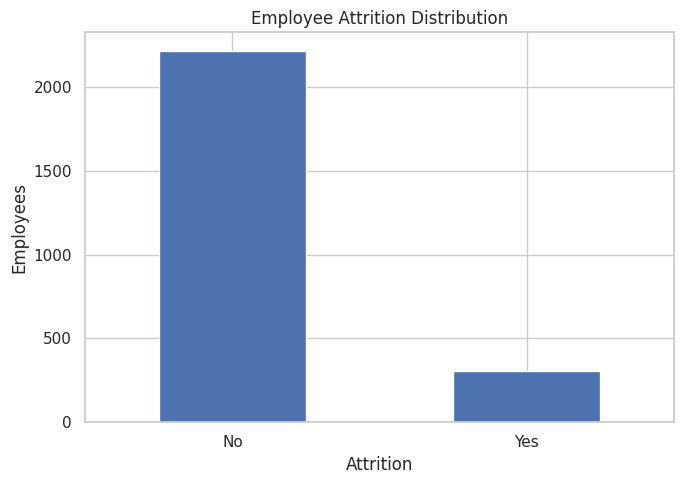

In [24]:
# Graph 1 — Attrition Distribution
plt.figure(figsize=(7, 5))
df["Attrition"].value_counts().reindex(["No", "Yes"]).plot(kind="bar")
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Employees")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Department
Human Resources           16.203704
Finance                   14.285714
It                        12.631579
Research & Development    12.079511
Marketing                 11.836735
Sales                     10.128205
Name: Attrition, dtype: float64

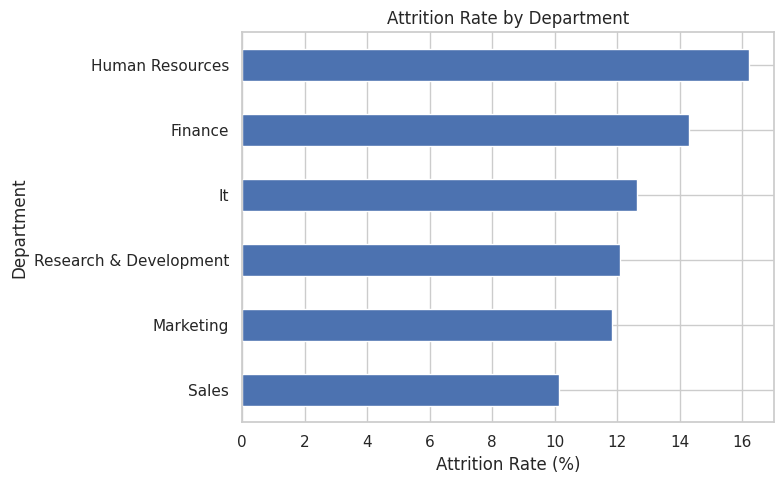

In [25]:
# Graph 2 — Attrition Rate by Department
department_attrition = (
    df.groupby("Department")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

display(department_attrition)

plt.figure(figsize=(8, 5))
department_attrition.sort_values().plot(kind="barh")
plt.title("Attrition Rate by Department")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Department")
plt.tight_layout()
plt.show()

OverTime
No          9.652928
Yes        18.918919
Unknown    10.000000
Name: Attrition, dtype: float64

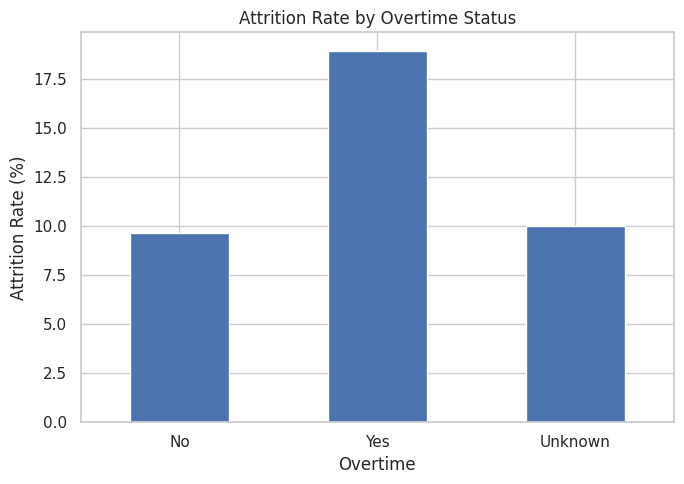

In [26]:
# Graph 3 — Attrition Rate by Overtime
overtime_attrition = (
    df.groupby("OverTime")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .reindex(["No", "Yes", "Unknown"])
)

display(overtime_attrition)

plt.figure(figsize=(7, 5))
overtime_attrition.plot(kind="bar")
plt.title("Attrition Rate by Overtime Status")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

SalarySlab
Medium        6.250000
High         10.647182
Very High    12.543554
Name: Attrition, dtype: float64

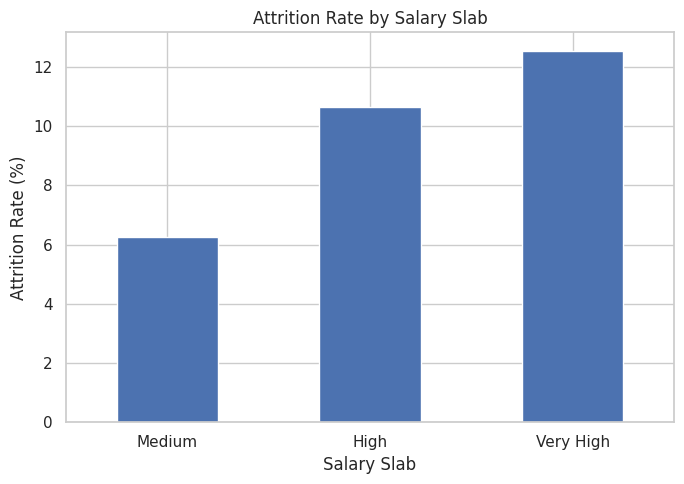

In [27]:
# Graph 4 — Attrition Rate by Salary Slab
salary_attrition = (
    df.groupby("SalarySlab")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .reindex(["Medium", "High", "Very High"])
)

display(salary_attrition)

plt.figure(figsize=(7, 5))
salary_attrition.plot(kind="bar")
plt.title("Attrition Rate by Salary Slab")
plt.xlabel("Salary Slab")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

JobRole
Finance Manager         18.518519
Financial Analyst       18.072289
HR Specialist           17.105263
HR Executive            16.216216
Research Scientist      13.548387
Software Engineer       12.903226
IT Support              12.745098
Research Director       12.345679
Marketing Specialist    12.048193
Manager                 11.544228
Name: Attrition, dtype: float64

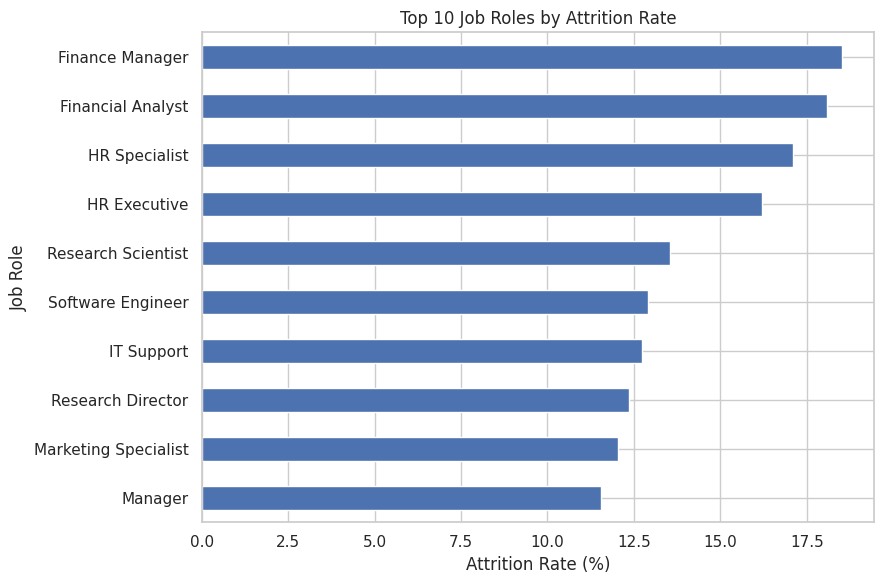

In [28]:
# Graph 5 — Top Job Roles by Attrition Rate
role_attrition = (
    df.groupby("JobRole")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .drop("Unknown", errors="ignore")
      .sort_values(ascending=False)
      .head(10)
)

display(role_attrition)

plt.figure(figsize=(9, 6))
role_attrition.sort_values().plot(kind="barh")
plt.title("Top 10 Job Roles by Attrition Rate")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")
plt.tight_layout()
plt.show()

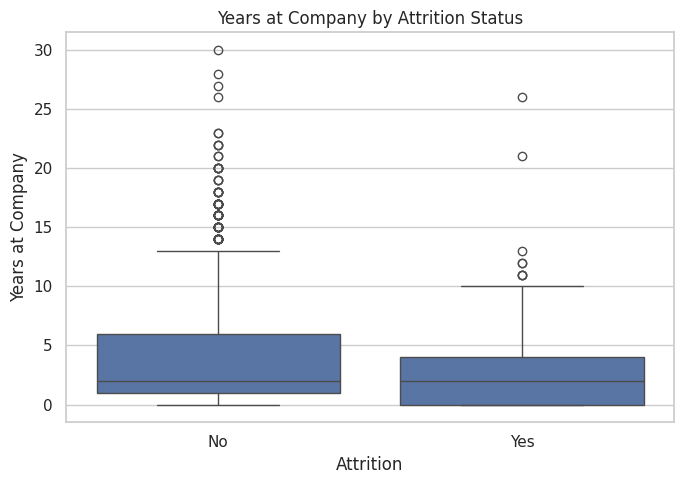

In [29]:
# Graph 6 — Tenure vs Attrition
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Attrition", y="YearsAtCompany")
plt.title("Years at Company by Attrition Status")
plt.xlabel("Attrition")
plt.ylabel("Years at Company")
plt.tight_layout()
plt.show()

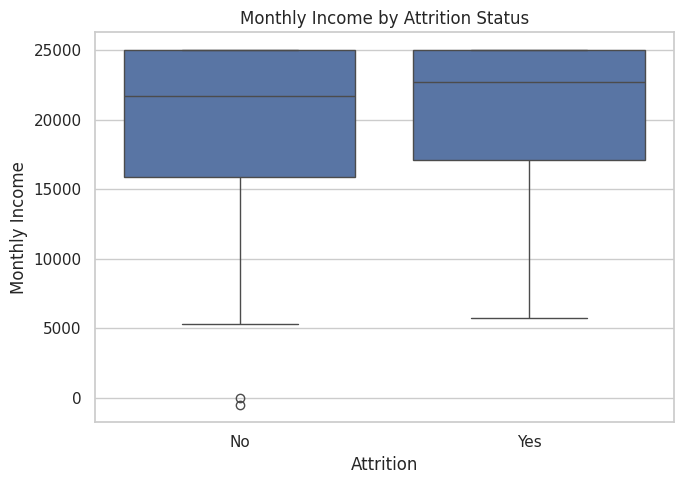

In [30]:
# Graph 7 — Monthly Income vs Attrition
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome")
plt.title("Monthly Income by Attrition Status")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.tight_layout()
plt.show()

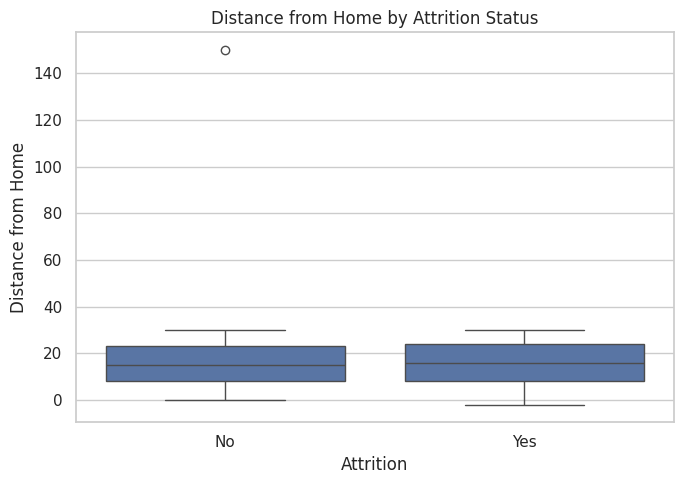

In [31]:
# Graph 8 — Distance from Home vs Attrition
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Attrition", y="DistanceFromHome")
plt.title("Distance from Home by Attrition Status")
plt.xlabel("Attrition")
plt.ylabel("Distance from Home")
plt.tight_layout()
plt.show()

## Business Insights

Based on the cleaned dataset:

- Overall attrition is approximately **12.1%**.
- **Overtime employees** have a noticeably higher attrition rate than employees without overtime.
- **Human Resources** has the highest department-level attrition rate in this dataset.
- Some finance and HR job roles show higher attrition rates than several other roles.
- Employees who left have **lower average tenure at the company** than employees who stayed.
- Distance from home is slightly higher on average among employees who left.
- Salary slab alone does not show a simple linear relationship with attrition, so HR should avoid treating salary band as the only driver.
- These are **associations in the dataset, not proof of causation**.

## Recommendations

1. Review workload and overtime patterns for teams with consistently high overtime.
2. Investigate retention issues in higher-risk departments and job roles.
3. Strengthen early-tenure support, onboarding, mentoring, and career development.
4. Combine salary, workload, satisfaction, tenure, and role information instead of relying on one variable.
5. Track attrition rates regularly using the same business definitions and data-quality checks.

## Conclusion

The analysis shows that employee attrition is concentrated around a few identifiable workforce patterns, especially overtime exposure, department/role differences, and shorter tenure. The cleaned dataset and visual analysis provide a foundation for HR teams to investigate retention risks and design targeted interventions.

**Note:** The analysis identifies relationships in the available data; it does not establish causal relationships.